### Robustness check using different strategies to calculate errors
- sensitivity test 
Construct error matrix
    - rank LLM response and get its percentile within the distribution of human responses 
        - accurate: percentile between 25% and 75%
        - under-represent (percentile < 25%): -1
        - over-represent (percentile > 75%): 1
    - alternative thresholds
        - 10 - 90
        - 20-80
        - 30-70
        - 40-60 
- robustness test using percentile rank scores
    - continuous value, no cutoff
- Error analysis by country
    - Among all items of a country, the number of under-/over-estimated items
- Error analysis by item
    - Among all countries of the given item, the number of under/over-estimated items
- Error pattern with religious and geographic distance

In [1]:
import textwrap 

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.stats import zscore, pearsonr

import pickle, json
import pandas as pd 
import numpy as np
from scipy import stats
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_validate, cross_val_score
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from statsmodels.regression.mixed_linear_model import MixedLM, VCSpec

from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances

from sklearn.metrics import silhouette_score
import geopandas as gpd
from sklearn.preprocessing import MinMaxScaler


from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

In [ ]:
# get the selected survey items
df_avg = pd.read_csv("./data/wvs7_country_avg.csv").set_index('Country')#.drop(columns=drop_columns)
items = list(df_avg.columns) # select the same items for the following dataframes
all_countries = list(df_avg.index)
df_avg.shape

(66, 117)

In [ ]:
df_wvs = pd.read_csv("./data/wvs7_scaled.csv")[['Country'] + items].set_index('Country')
df_wvs.shape

(97220, 117)

In [ ]:
# LLM country representation
# make sure rows/countries and columns/items have consistent orders
df_gpt = pd.read_csv("./data/gpt_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries]
df_claude = pd.read_csv("./data/claude_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries]
df_deepseek = pd.read_csv("./data/deepseek_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries]

df_gpt.shape, df_claude.shape, df_deepseek.shape

((66, 117), (66, 117), (66, 117))

In [ ]:
df_c2q = pd.read_csv('./data/Maps - code2question.csv')
df_c2q['question'] = df_c2q['s_category'] + ': ' + df_c2q['q_content']

In [ ]:
# map to country abbreviations
with open('./data/country_abr.json','r') as f:
    abr_map = json.load(f)

df_abr = pd.DataFrame(list(abr_map.items()), columns=["abr", "country"])
df_abr.head()

,abr,country
0,CAN,Canada
1,IDN,Indonesia
2,CHN,China
3,GBR,United Kingdom
4,USA,United States


In [ ]:
df_GDP = pd.read_csv('./data/GDP_per_capita.csv').set_index('Country Name')

with open('./data/culture_dist2US_CHN.pkl', 'rb') as f:
    df_culture_dist = pickle.load(f)

In [8]:
# LLM country representation
df_llm = df_gpt # df_gpt, df_claude, df_deepseek
llm_name = "GPT" # GPT, Claude, DeepSeek


#### Construct error matrix using alternative thresholds

In [9]:
def error_matrix_bythresh(lw_thresh):
    up_thresh = 1 - lw_thresh
    df_lw = df_wvs.groupby(df_wvs.index).quantile(lw_thresh).reindex(index=all_countries, columns=items)
    df_up = df_wvs.groupby(df_wvs.index).quantile(up_thresh).reindex(index=all_countries, columns=items)
    v_llm = df_llm.reindex(index=all_countries, columns=items)

    matrix = np.select(
        [v_llm < df_lw, v_llm > df_up],
        [-1, 1],
        default=0
    )
    return pd.DataFrame(matrix, index=all_countries, columns=items)

df_outlier_10 = error_matrix_bythresh(lw_thresh = 0.1)
df_outlier_20 = error_matrix_bythresh(lw_thresh = 0.2)
df_outlier_25 = error_matrix_bythresh(lw_thresh = 0.25)
df_outlier_30 = error_matrix_bythresh(lw_thresh = 0.3)
df_outlier_40 = error_matrix_bythresh(lw_thresh = 0.4)

In [10]:
def test_match():
    # check the similarity between df_error and df_error_25
    match = (df_outlier_40 == df_outlier_25)
    match_rate = match.values.mean()
    print(f"Match rate: {match_rate:.4f} ({match_rate*100:.2f}%)")
    print(f"Mismatches: {(~match).values.sum()} / {match.size}")
    return match_rate

test_match()

Match rate: 0.7776 (77.76%)
Mismatches: 1717 / 7722


np.float64(0.7776482776482776)

- pearson correlation between different error cutoff

In [11]:
def organize_error(df_outlier):
    
    df_error_byCtry = pd.DataFrame({
                'misrepresentation': ((df_outlier != 0).sum(axis=1)).round(3),
                'accuracy': ((df_outlier == 0).sum(axis=1)).round(3),
                'over_estimate':  ((df_outlier == 1).sum(axis=1)).round(3),
                'under_estimate': ((df_outlier == -1).sum(axis=1)).round(3),
            }, index=all_countries)

    df_error_byItem = pd.DataFrame({
            'misrepresentation': ((df_outlier != 0).sum(axis=0)).round(3),
            'accuracy': ((df_outlier == 0).sum(axis=0)).round(3),
            'over_estimate':  ((df_outlier == 1).sum(axis=0)).round(3),
            'under_estimate': ((df_outlier == -1).sum(axis=0)).round(3),
        }, index=items)

    return df_error_byCtry, df_error_byItem

df_error_byCtry_10, df_error_byItem_10 = organize_error(df_outlier_10)
df_error_byCtry_20, df_error_byItem_20 = organize_error(df_outlier_20)
df_error_byCtry_25, df_error_byItem_25 = organize_error(df_outlier_25)
df_error_byCtry_30, df_error_byItem_30 = organize_error(df_outlier_30)
df_error_byCtry_40, df_error_byItem_40 = organize_error(df_outlier_40)

In [12]:
df_error_byItem_10

,misrepresentation,accuracy,over_estimate,under_estimate
A001,0,66,0,0
A002,0,66,0,0
A003,0,66,0,0
A004,1,65,1,0
A005,0,66,0,0
...,...,...,...,...
H008_03,1,65,1,0
H008_04,1,65,1,0
H008_07,0,66,0,0
H008_08,0,66,0,0


In [13]:
def calculate_corr():
    # correlation between country rankings under different threshold
    # correlation between item rankings under different threshold
    ctry_baseline = df_error_byCtry_25['accuracy']
    item_baseline = df_error_byItem_25['accuracy']
    thresholds = [10, 20, 30, 40]
    ctry_dfs      = [df_error_byCtry_10, df_error_byCtry_20, df_error_byCtry_30, df_error_byCtry_40]
    item_dfs      = [df_error_byItem_10, df_error_byItem_20, df_error_byItem_30, df_error_byItem_40]

    rows = []
    for thresh, df_ctry, df_item in zip(thresholds, ctry_dfs, item_dfs):
        r_ctry, p_ctry = pearsonr(ctry_baseline, df_ctry['accuracy'])
        r_item, p_item = pearsonr(item_baseline, df_item['accuracy'])
        rows.append({'threshold': thresh, 
                     'r_ctry': round(r_ctry, 3), 'p_ctry': round(p_ctry, 3),
                     'r_item': round(r_item, 3), 'p_item': round(p_item, 3)})

    return pd.DataFrame(rows).set_index('threshold')

calculate_corr()

,r_ctry,p_ctry,r_item,p_item
threshold,,,,
10,0.734,0.0,0.793,0.0
20,0.923,0.0,0.973,0.0
30,0.935,0.0,0.968,0.0
40,0.793,0.0,0.874,0.0


#### sensitivity tests for GDP effect 

In [ ]:
def check_GDP_effect(thresh, df_error_byCtry, column):
    
    df_error_byCtry['abr'] = df_error_byCtry_25.index.map(df_abr.set_index('country')['abr'])

    df_merged = df_error_byCtry.merge(
        df_GDP.reset_index(),
        left_on='abr',
        right_on='Country Code',
        how='inner'
    )
   
    df_plot = df_merged.dropna(subset=[column])
    print(df_plot.shape)
    
    x, y = df_plot[column], df_plot['accuracy']
    r, p = stats.pearsonr(x, y)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(x, y, alpha=0.6, s=40)

    slope, intercept, _, _, std_err = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='red', linewidth=1.5)


    n = len(x)
    t_crit = stats.t.ppf(0.975, df=n - 2)
    Sxx = ((x - x.mean())**2).sum()
    se_line = std_err * np.sqrt(Sxx / n + (x_line - x.mean())**2)
    ax.fill_between(x_line, y_line - t_crit * se_line, y_line + t_crit * se_line,
                    color="red", alpha=0.2, linewidth=0)

    ax.set_xlabel("Log (GDP Per Capita)", fontsize=15)
    ax.set_ylabel('Correctly Represented Items Per Country', fontsize=15)
    # ax.set_ylim(0, 40)
    ax.tick_params(axis='both', labelsize=17)

    from matplotlib.lines import Line2D
    p_str = 'p < .001' if p < 0.001 else f'p = {p:.3f}'

    print(f"[{llm_name}] Accuracy ~ {column}")
    print(f"  r={r:.3f}, {p_str}")
    print(f"  slope={slope:.3f}, intercept={intercept:.3f}")
    
    stat_handle = Line2D([0], [0], color="none", label=f"r={r:.3f}\n{p_str}")
    ax.legend(handles=[stat_handle], fontsize=16, loc="upper left", frameon=False)
    ax.set_title(f"{llm_name} Accuracy at {thresh} VS Country GDP", fontsize=17, fontweight="bold", pad=10)
    # plt.savefig('./supfig/2B_corrGDP_'+llm_name+'_byAccuracy.png', dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show() 



(63, 13)
[GPT] Accuracy ~ log(GDP_avg)
  r=0.346, p = 0.005
  slope=0.914, intercept=105.390


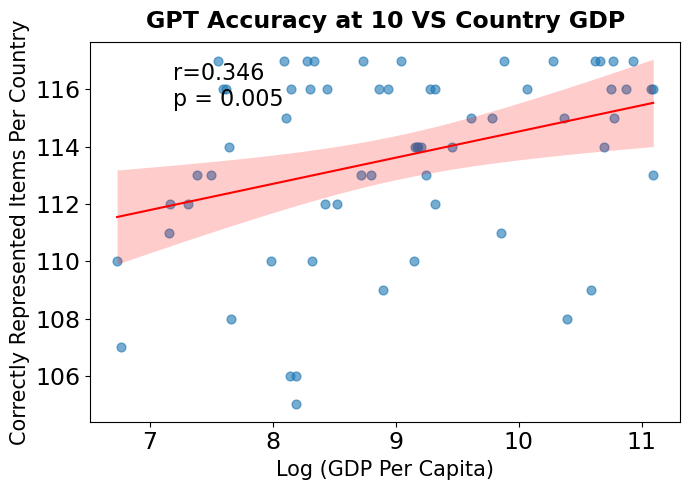

(63, 13)
[GPT] Accuracy ~ log(GDP_avg)
  r=0.508, p < .001
  slope=2.646, intercept=79.967


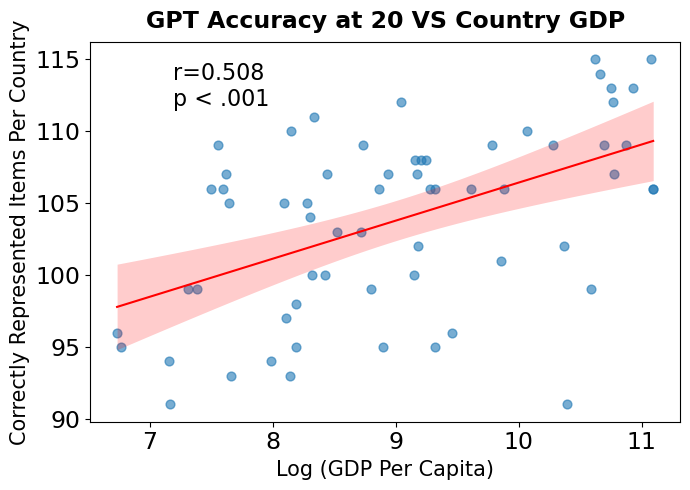

(63, 13)
[GPT] Accuracy ~ log(GDP_avg)
  r=0.648, p < .001
  slope=4.020, intercept=61.447


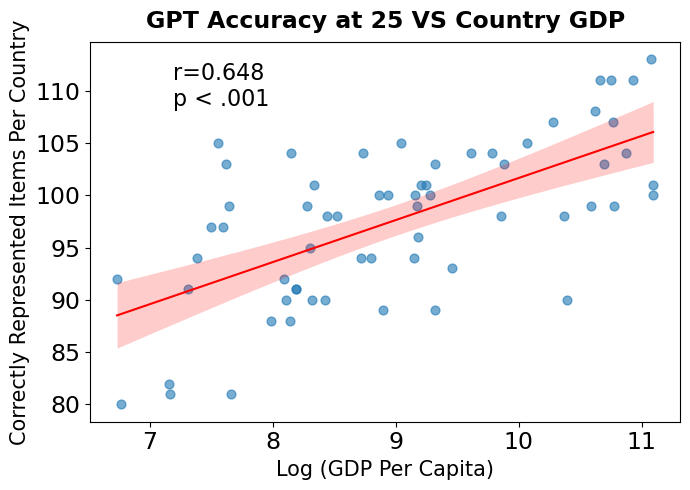

(63, 13)
[GPT] Accuracy ~ log(GDP_avg)
  r=0.614, p < .001
  slope=4.570, intercept=48.790


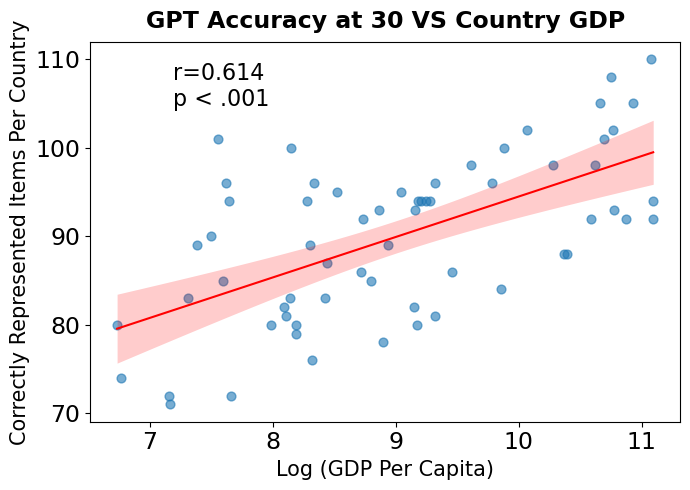

(63, 13)
[GPT] Accuracy ~ log(GDP_avg)
  r=0.611, p < .001
  slope=4.686, intercept=29.405


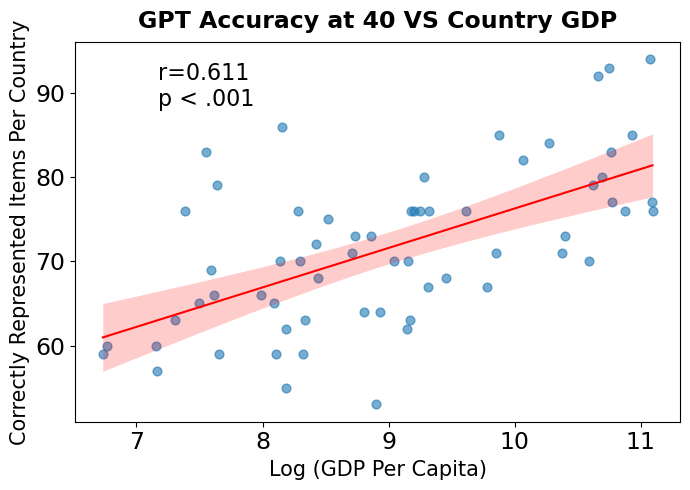

In [15]:
for thresh, df_error_byCtry in zip([10, 20, 25, 30, 40] ,
                                   [df_error_byCtry_10, df_error_byCtry_20, df_error_byCtry_25, df_error_byCtry_30, df_error_byCtry_40]):
    check_GDP_effect(thresh, df_error_byCtry, 'log(GDP_avg)')

#### sensitive tests for culture distance effect

In [ ]:
def check_culturedist_effect(thresh, df_error_byCtry, df_culture_dist):
    df_plot = df_error_byCtry.join(df_culture_dist[["dist2US", "dist2CHN"]], how="inner").dropna(subset=["dist2US", "dist2CHN"])

    col, xlabel = "dist2US", "Cultural Distance to US"

    df_plot['accuracy'] =  df_avg.shape[1] - df_plot['misrepresentation']
    x, y = df_plot[col], df_plot['accuracy']

    r, p = stats.pearsonr(x, y)
    slope, intercept, _, _, std_err = stats.linregress(x, y)
    n = len(x)

    p_str = "p < .001" if p < 0.001 else f"p = {p:.3f}"
    print(f"[{llm_name}] Accuracy ~ {xlabel}")
    print(f"  n={n}, r={r:.3f}, {p_str}")
    print(f"  slope={slope:.3f}, intercept={intercept:.3f}")

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(x, y, alpha=0.6, s=40)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color="red", linewidth=1.5)

    t_crit = stats.t.ppf(0.975, df=n - 2)
    Sxx = ((x - x.mean())**2).sum()
    se_line = std_err * np.sqrt(Sxx / n + (x_line - x.mean())**2)
    ax.fill_between(x_line, y_line - t_crit * se_line, y_line + t_crit * se_line,
                    color="red", alpha=0.2, linewidth=0)

    ax.set_xlabel(xlabel, fontsize=15)
    ax.set_ylabel("Correctly Represented Items Per Country", fontsize=15)
    # ax.set_ylim(0, 40)
    ax.tick_params(axis="both", labelsize=17)

    from matplotlib.lines import Line2D
    stat_handle = Line2D([0], [0], color="none", label=f"r={r:.3f}\n{p_str}")
    ax.legend(handles=[stat_handle], fontsize=14, loc="upper right", frameon=False)
    ax.set_title(f"{llm_name} Accuracy by {thresh} vs Cultural Distance", fontsize=17, fontweight="bold", pad=10)

    plt.tight_layout()
    # plt.savefig("./supfig/2B_corrCultureDist2US_"+llm_name+"_byAccuracy.png", dpi=300, bbox_inches="tight")
    plt.show()

[GPT] Accuracy ~ Cultural Distance to US
  n=50, r=-0.378, p = 0.007
  slope=-24.926, intercept=116.444


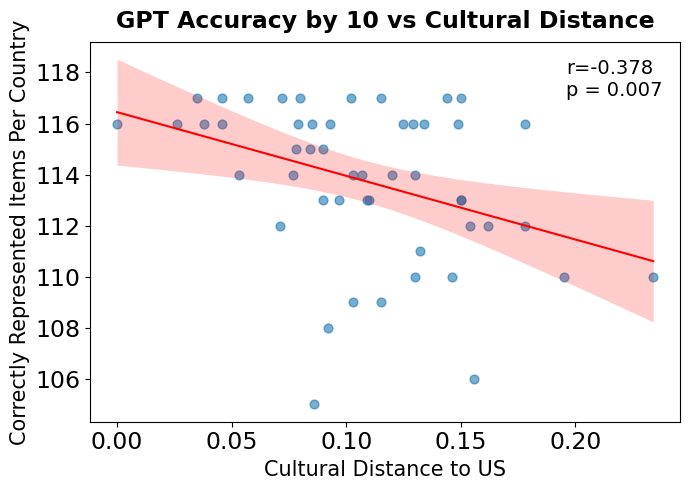

[GPT] Accuracy ~ Cultural Distance to US
  n=50, r=-0.481, p < .001
  slope=-64.118, intercept=111.306


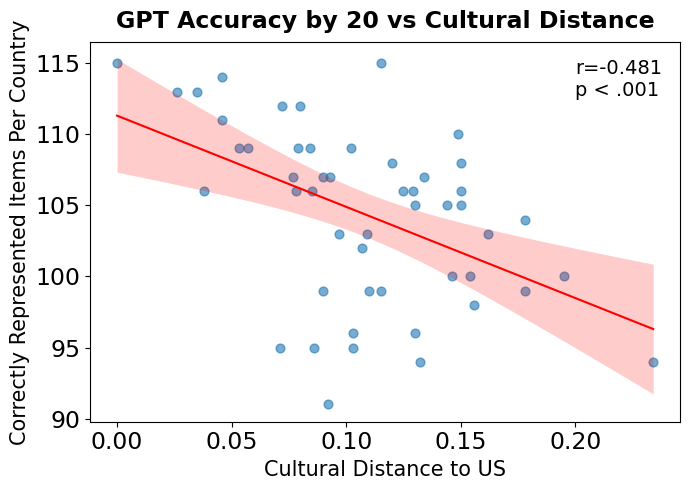

[GPT] Accuracy ~ Cultural Distance to US
  n=50, r=-0.625, p < .001
  slope=-94.078, intercept=108.692


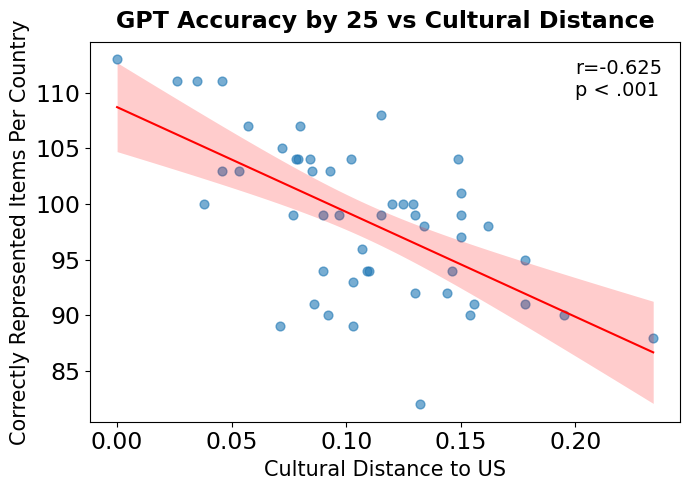

[GPT] Accuracy ~ Cultural Distance to US
  n=50, r=-0.578, p < .001
  slope=-106.992, intercept=102.383


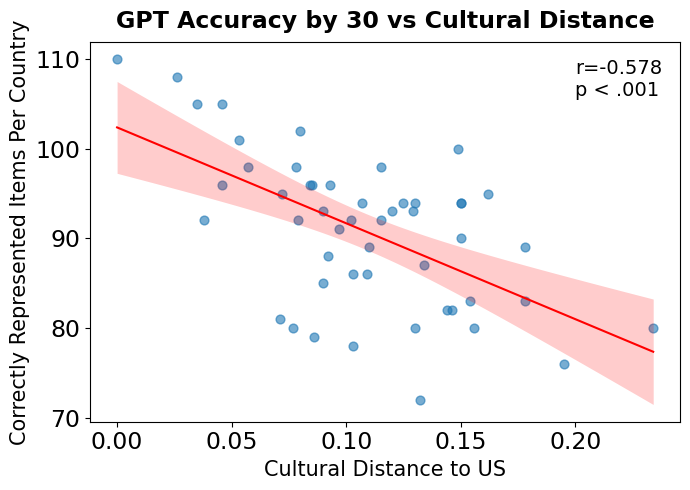

[GPT] Accuracy ~ Cultural Distance to US
  n=50, r=-0.512, p < .001
  slope=-102.970, intercept=83.570


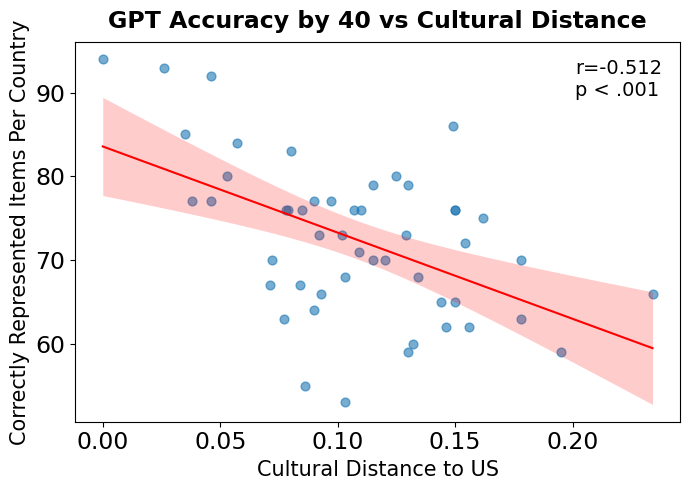

In [17]:
for thresh, df_error_byCtry in zip([10, 20, 25, 30, 40] ,
                                   [df_error_byCtry_10, df_error_byCtry_20, df_error_byCtry_25, df_error_byCtry_30, df_error_byCtry_40]):
    check_culturedist_effect(thresh, df_error_byCtry, df_culture_dist)
    

In [18]:
def summarize_error():
    thresholds = [10, 20, 25, 30, 40]
    ctry_dfs = [df_error_byCtry_10, df_error_byCtry_20, df_error_byCtry_25, df_error_byCtry_30, df_error_byCtry_40]
    item_dfs = [df_error_byItem_10, df_error_byItem_20, df_error_byItem_25, df_error_byItem_30, df_error_byItem_40]

    rows = []
    for thresh, ctry_df, item_df in zip(thresholds, ctry_dfs, item_dfs):
        # rows.append({
        #     'threshold':              thresh,
        #     'misrepresentation':      round(ctry_df['misrepresentation'].mean(),3),
        #     'under_estimate (by ctry)':  round(ctry_df['under_estimate'].mean(),3),
        #     'over_estimate (by ctry)':   round(ctry_df['over_estimate'].mean(), 3),
        #     'under_estimate (by item)':  round(item_df['under_estimate'].mean(), 3),
        #     'over_estimate (by item)':   round(item_df['over_estimate'].mean(), 3),
            
        # })

        rows.append({
                    'threshold':              thresh,
                    'misrepresentation':      int(round(ctry_df['misrepresentation'].mean())),
                    'under_estimate (by ctry)':  int(round(ctry_df['under_estimate'].mean())),
                    'over_estimate (by ctry)':   int(round(ctry_df['over_estimate'].mean())),
                    'under_estimate (by item)':  int(round(item_df['under_estimate'].mean())),
                    'over_estimate (by item)':   int(round(item_df['over_estimate'].mean())),
                    
                })

    return pd.DataFrame(rows).set_index('threshold')


In [19]:
summarize_error()

,misrepresentation,under_estimate (by ctry),over_estimate (by ctry),under_estimate (by item),over_estimate (by item)
threshold,,,,,
10,3,1,2,1,1
20,13,4,9,2,5
25,19,7,13,4,7
30,27,9,18,5,10
40,45,16,29,9,16


#### Robustness check based on continuous percentile scores

In [20]:
def rank_percentile(values, x):
    # the percentile of x in the distribution of values
    below = sum(v < x for v in values)
    equal = sum(v == x for v in values)

    return (below + 0.5 * equal) / len(values)

def calculate_response_percentile():
    """
    calculate where the LLM response lies in the corresponding human distribution
    """
    # Iterate over each country and each item, calculate the item percentile
    ctry_percentile = {}
    for ctry in all_countries:
        df_ctry = df_wvs.loc[ctry]
        llm_arr = df_llm.loc[ctry].values
        
        # for each item, calculate the percentile and response share
        v_perc = []
        v_share = []
        for ci, col in enumerate(items):
            v_perc.append(rank_percentile(df_ctry[col], llm_arr[ci]).round(3))
            v_share.append((df_ctry[col] == llm_arr[ci]).mean().round(3))
        ctry_percentile[ctry] = v_perc
        
    return pd.DataFrame(ctry_percentile).T.rename(columns={i: items[i] for i in range(len(items))})

df_percentile = calculate_response_percentile()

In [21]:
def organize_error_bydev():

    # deviation from the human median, deviation as error
    df_dev = df_percentile - 0.5
    df_dev_byCtry = pd.DataFrame({
                'misrepresentation': (abs(df_dev).mean(axis=1)).round(3),
                'over_estimate':  (df_dev[df_dev > 0].mean(axis=1)).round(3),
                'under_estimate': (df_dev[df_dev < 0].mean(axis=1)).round(3),
            }, index=all_countries)
    
    df_dev_byItem = pd.DataFrame({
            'misrepresentation': (abs(df_dev).mean(axis=0)).round(3),
            'over_estimate':  (df_dev[df_dev > 0].mean(axis=0)).round(3),
            'under_estimate': (df_dev[df_dev < 0].mean(axis=0)).round(3),
        }, index=items)

    df_dev_byCtry['accuracy'] = 0.5 - df_dev_byCtry['misrepresentation']
    df_dev_byItem['accuracy'] = 0.5 - df_dev_byItem['misrepresentation']

    return df_dev_byCtry, df_dev_byItem

df_dev_byCtry, df_dev_byItem = organize_error_bydev()

- country ranking correlation, by accuracy

In [27]:
r_ctry, p_ctry = pearsonr(df_error_byCtry_25['accuracy'], df_dev_byCtry['accuracy'])
r_item, p_item = pearsonr(df_error_byItem_25['accuracy'], df_dev_byItem['accuracy'])

print(r_ctry.round(3), p_ctry.round(3), r_item.round(3), p_item.round(3))

0.806 0.0 0.796 0.0


(63, 13)
[GPT] Accuracy ~ log(GDP_avg)
  r=0.377, p = 0.002
  slope=0.006, intercept=0.242


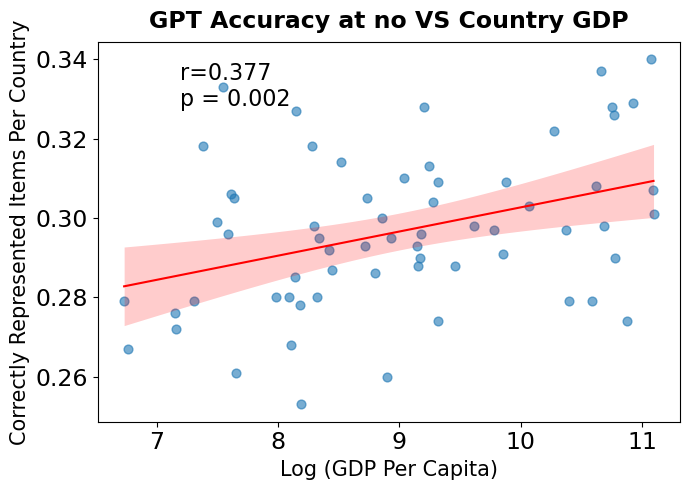

In [24]:
check_GDP_effect('no', df_dev_byCtry, 'log(GDP_avg)')

[GPT] Accuracy ~ Cultural Distance to US
  n=50, r=-0.384, p = 0.006
  slope=-0.159, intercept=116.815


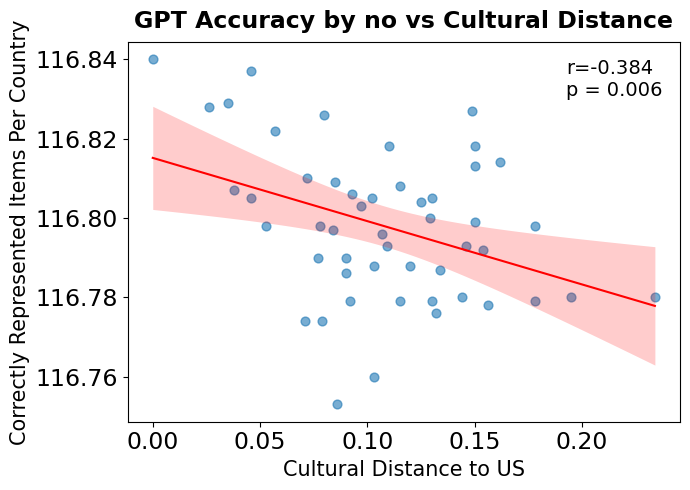

In [25]:
check_culturedist_effect("no", df_dev_byCtry, df_culture_dist)

In [26]:
# summarize error
print(
    f"average deviation: {round(df_dev_byCtry['misrepresentation'].mean(), 3)}, "
    f"under_estimate (by ctry): {round(df_dev_byCtry['under_estimate'].mean(), 3)}, "
    f"over_estimate (by ctry): {round(df_dev_byCtry['over_estimate'].mean(), 3)}, "
    f"under_estimate (by item): {round(df_dev_byItem['under_estimate'].mean(), 3)}, "
    f"over_estimate (by item): {round(df_dev_byItem['over_estimate'].mean(), 3)}"
)


average deviation: 0.203, under_estimate (by ctry): -0.188, over_estimate (by ctry): 0.215, under_estimate (by item): -0.165, over_estimate (by item): 0.203


### Replicate results for Claude

In [28]:
# LLM country representation
df_llm = df_claude 
llm_name = "Claude" 

In [29]:
df_outlier_10 = error_matrix_bythresh(lw_thresh = 0.1)
df_outlier_20 = error_matrix_bythresh(lw_thresh = 0.2)
df_outlier_25 = error_matrix_bythresh(lw_thresh = 0.25)
df_outlier_30 = error_matrix_bythresh(lw_thresh = 0.3)
df_outlier_40 = error_matrix_bythresh(lw_thresh = 0.4)

In [30]:
df_error_byCtry_10, df_error_byItem_10 = organize_error(df_outlier_10)
df_error_byCtry_20, df_error_byItem_20 = organize_error(df_outlier_20)
df_error_byCtry_25, df_error_byItem_25 = organize_error(df_outlier_25)
df_error_byCtry_30, df_error_byItem_30 = organize_error(df_outlier_30)
df_error_byCtry_40, df_error_byItem_40 = organize_error(df_outlier_40)

In [31]:
calculate_corr()

,r_ctry,p_ctry,r_item,p_item
threshold,,,,
10,0.672,0.0,0.766,0.0
20,0.901,0.0,0.964,0.0
30,0.941,0.0,0.961,0.0
40,0.786,0.0,0.813,0.0


(63, 13)
[Claude] Accuracy ~ log(GDP_avg)
  r=0.151, p = 0.238
  slope=0.292, intercept=111.808


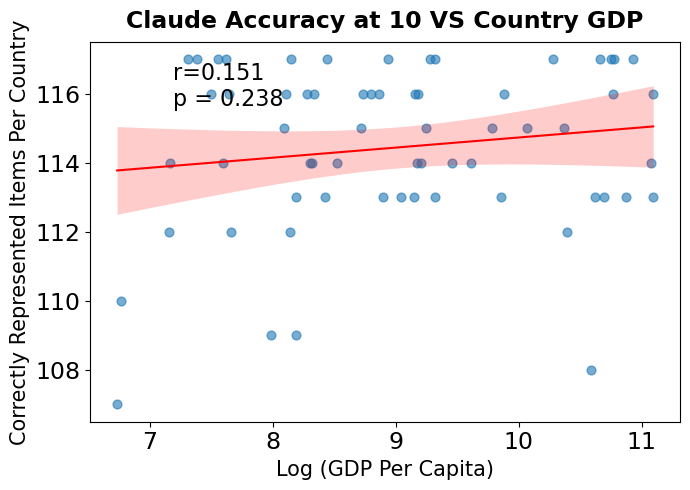

(63, 13)
[Claude] Accuracy ~ log(GDP_avg)
  r=0.374, p = 0.003
  slope=1.564, intercept=92.376


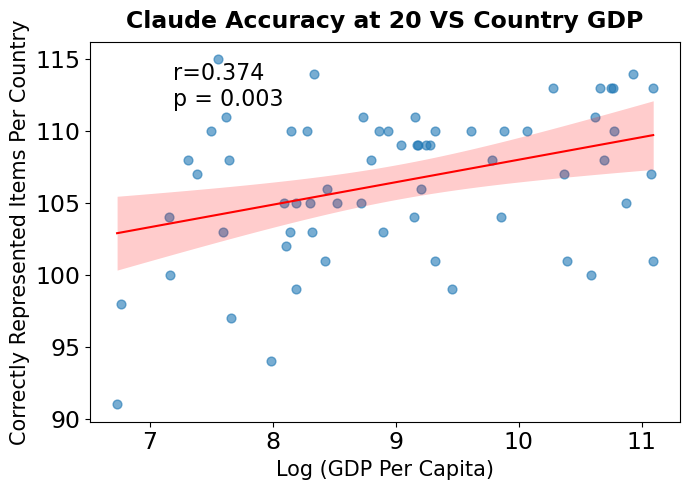

(63, 13)
[Claude] Accuracy ~ log(GDP_avg)
  r=0.544, p < .001
  slope=3.060, intercept=72.863


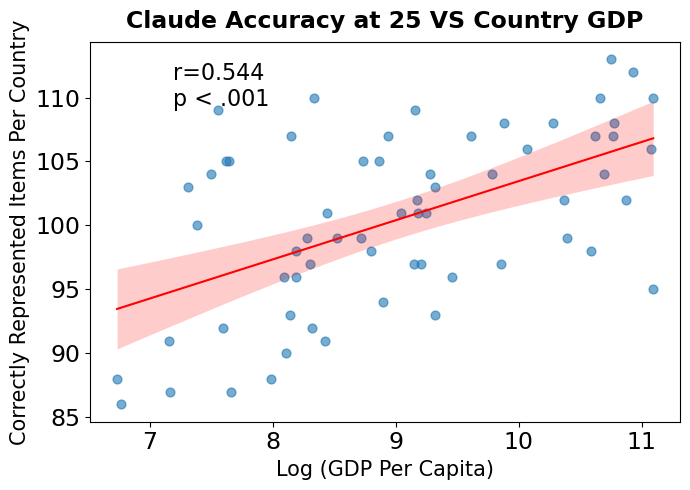

(63, 13)
[Claude] Accuracy ~ log(GDP_avg)
  r=0.547, p < .001
  slope=3.906, intercept=57.074


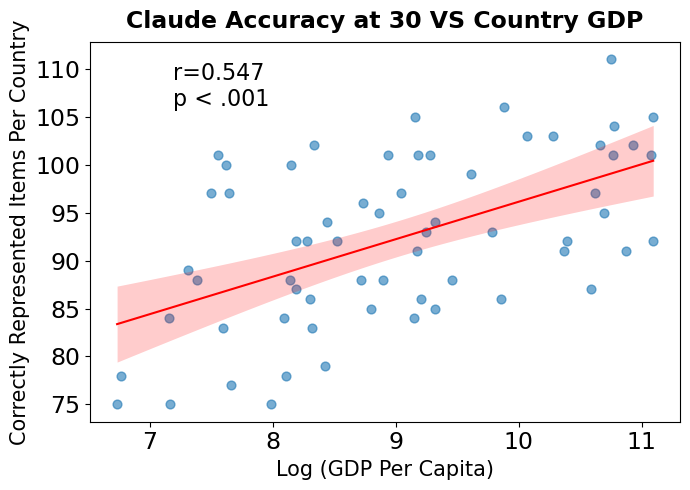

(63, 13)
[Claude] Accuracy ~ log(GDP_avg)
  r=0.637, p < .001
  slope=4.799, intercept=29.964


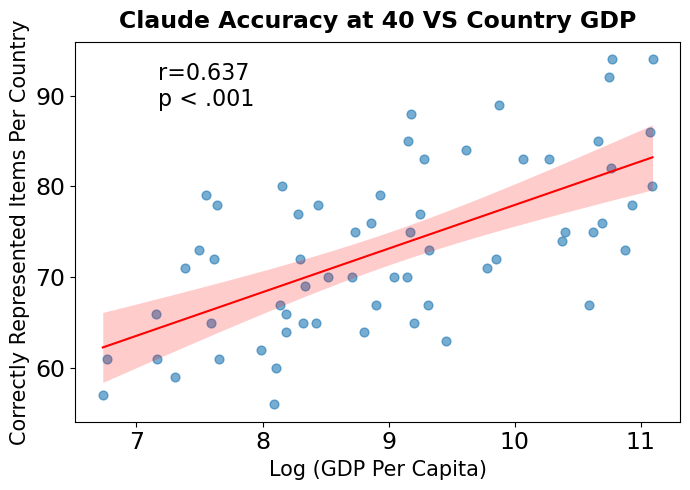

In [32]:
for thresh, df_error_byCtry in zip([10, 20, 25, 30, 40] ,
                                   [df_error_byCtry_10, df_error_byCtry_20, df_error_byCtry_25, df_error_byCtry_30, df_error_byCtry_40]):
    check_GDP_effect(thresh, df_error_byCtry, 'log(GDP_avg)')

[Claude] Accuracy ~ Cultural Distance to US
  n=50, r=-0.186, p = 0.195
  slope=-9.887, intercept=115.525


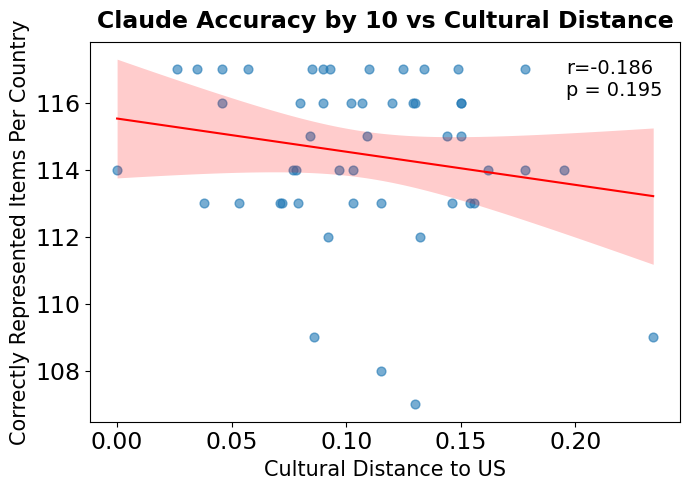

[Claude] Accuracy ~ Cultural Distance to US
  n=50, r=-0.384, p = 0.006
  slope=-41.076, intercept=111.144


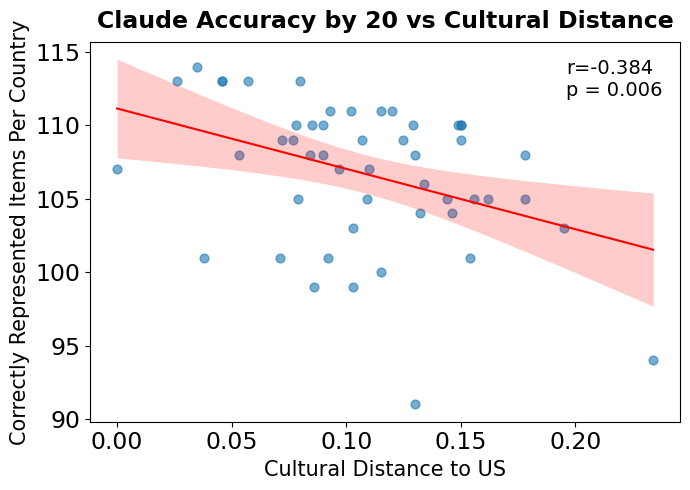

[Claude] Accuracy ~ Cultural Distance to US
  n=50, r=-0.529, p < .001
  slope=-68.836, intercept=108.614


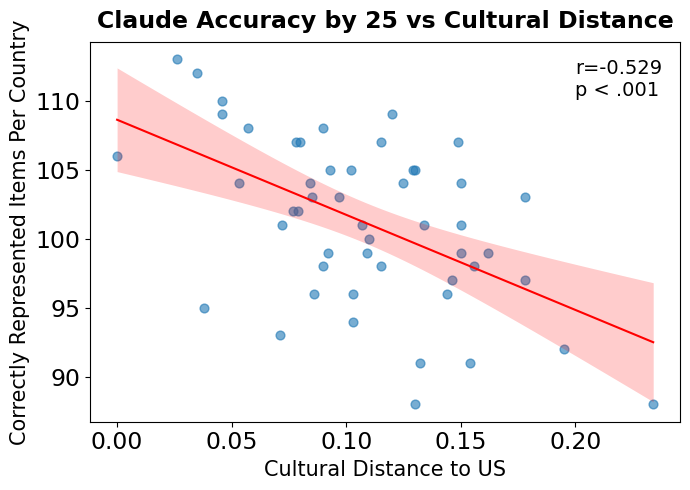

[Claude] Accuracy ~ Cultural Distance to US
  n=50, r=-0.562, p < .001
  slope=-94.826, intercept=103.293


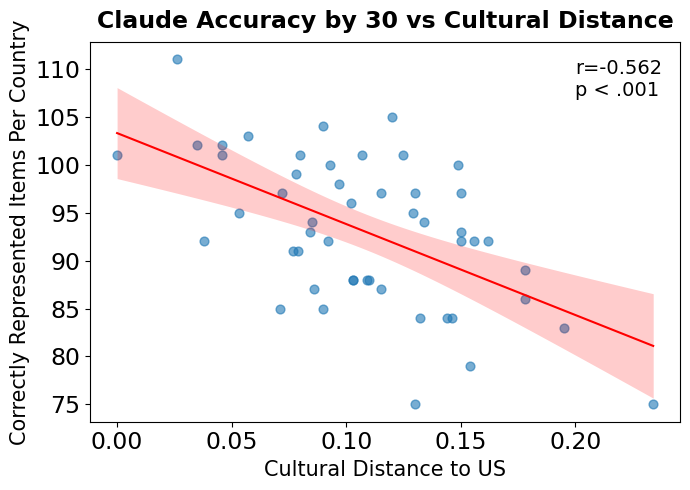

[Claude] Accuracy ~ Cultural Distance to US
  n=50, r=-0.520, p < .001
  slope=-98.950, intercept=84.677


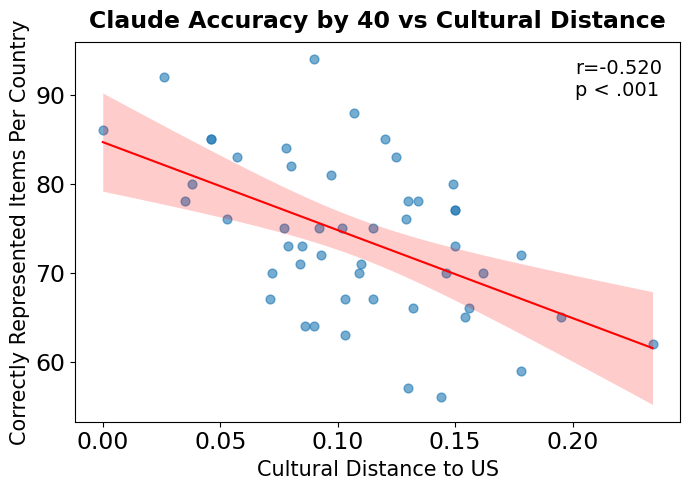

In [33]:
for thresh, df_error_byCtry in zip([10, 20, 25, 30, 40] ,
                                   [df_error_byCtry_10, df_error_byCtry_20, df_error_byCtry_25, df_error_byCtry_30, df_error_byCtry_40]):
    check_culturedist_effect(thresh, df_error_byCtry, df_culture_dist)
    

In [34]:
summarize_error()

,misrepresentation,under_estimate (by ctry),over_estimate (by ctry),under_estimate (by item),over_estimate (by item)
threshold,,,,,
10,3,1,2,0,1
20,10,3,7,2,4
25,16,6,10,3,6
30,25,10,15,5,8
40,44,19,25,11,14


In [35]:
df_percentile = calculate_response_percentile()

In [36]:
df_dev_byCtry, df_dev_byItem = organize_error_bydev()

In [37]:
r_ctry, p_ctry = pearsonr(df_error_byCtry_25['accuracy'], df_dev_byCtry['accuracy'])
r_item, p_item = pearsonr(df_error_byItem_25['accuracy'], df_dev_byItem['accuracy'])

print(r_ctry.round(3), p_ctry.round(3), r_item.round(3), p_item.round(3))

0.785 0.0 0.761 0.0


(63, 13)
[Claude] Accuracy ~ log(GDP_avg)
  r=0.352, p = 0.005
  slope=0.005, intercept=0.262


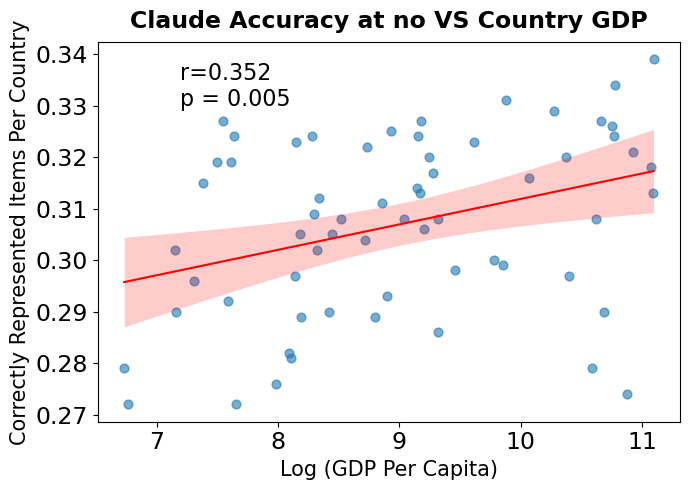

In [38]:
check_GDP_effect('no', df_dev_byCtry, 'log(GDP_avg)')

[Claude] Accuracy ~ Cultural Distance to US
  n=50, r=-0.285, p = 0.045
  slope=-0.099, intercept=116.819


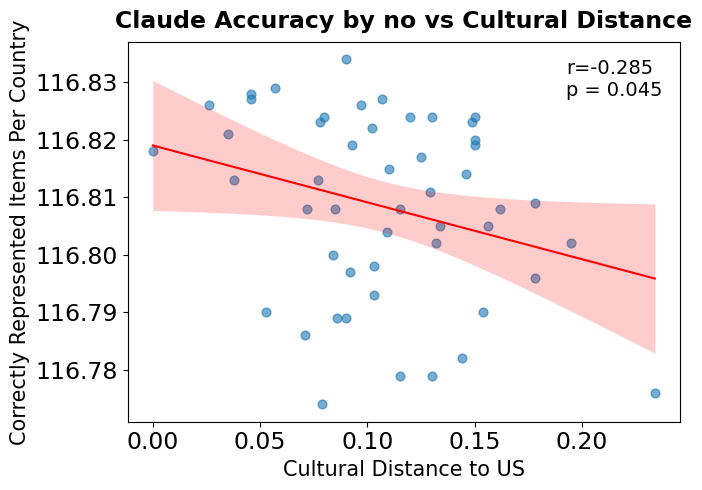

In [39]:
check_culturedist_effect("no", df_dev_byCtry, df_culture_dist)

In [40]:
# summarize error
print(
    f"average deviation: {round(df_dev_byCtry['misrepresentation'].mean(), 3)}, "
    f"under_estimate (by ctry): {round(df_dev_byCtry['under_estimate'].mean(), 3)}, "
    f"over_estimate (by ctry): {round(df_dev_byCtry['over_estimate'].mean(), 3)}, "
    f"under_estimate (by item): {round(df_dev_byItem['under_estimate'].mean(), 3)}, "
    f"over_estimate (by item): {round(df_dev_byItem['over_estimate'].mean(), 3)}"
)


average deviation: 0.193, under_estimate (by ctry): -0.18, over_estimate (by ctry): 0.204, under_estimate (by item): -0.157, over_estimate (by item): 0.187


### Replicate results for DeepSeek

In [41]:
# LLM country representation
df_llm = df_deepseek 
llm_name = "DeepSeek" 

In [42]:
df_outlier_10 = error_matrix_bythresh(lw_thresh = 0.1)
df_outlier_20 = error_matrix_bythresh(lw_thresh = 0.2)
df_outlier_25 = error_matrix_bythresh(lw_thresh = 0.25)
df_outlier_30 = error_matrix_bythresh(lw_thresh = 0.3)
df_outlier_40 = error_matrix_bythresh(lw_thresh = 0.4)

In [43]:
df_error_byCtry_10, df_error_byItem_10 = organize_error(df_outlier_10)
df_error_byCtry_20, df_error_byItem_20 = organize_error(df_outlier_20)
df_error_byCtry_25, df_error_byItem_25 = organize_error(df_outlier_25)
df_error_byCtry_30, df_error_byItem_30 = organize_error(df_outlier_30)
df_error_byCtry_40, df_error_byItem_40 = organize_error(df_outlier_40)

In [44]:
calculate_corr()

,r_ctry,p_ctry,r_item,p_item
threshold,,,,
10,0.650,0.0,0.828,0.0
20,0.894,0.0,0.962,0.0
30,0.917,0.0,0.952,0.0
40,0.766,0.0,0.803,0.0


(63, 13)
[DeepSeek] Accuracy ~ log(GDP_avg)
  r=0.227, p = 0.074
  slope=0.430, intercept=110.806


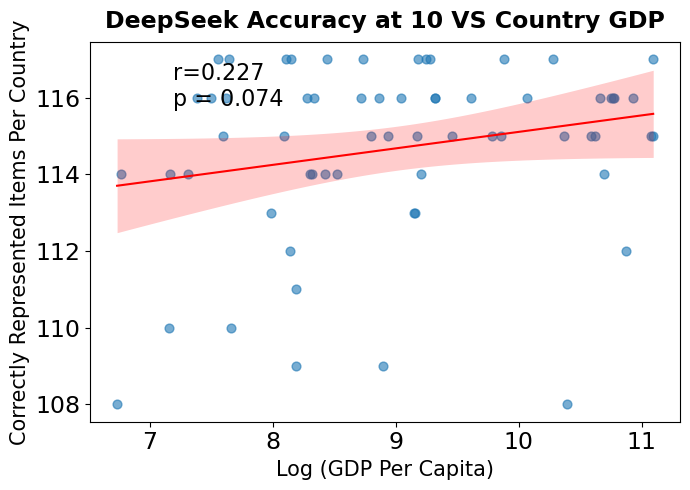

(63, 13)
[DeepSeek] Accuracy ~ log(GDP_avg)
  r=0.285, p = 0.024
  slope=1.115, intercept=97.551


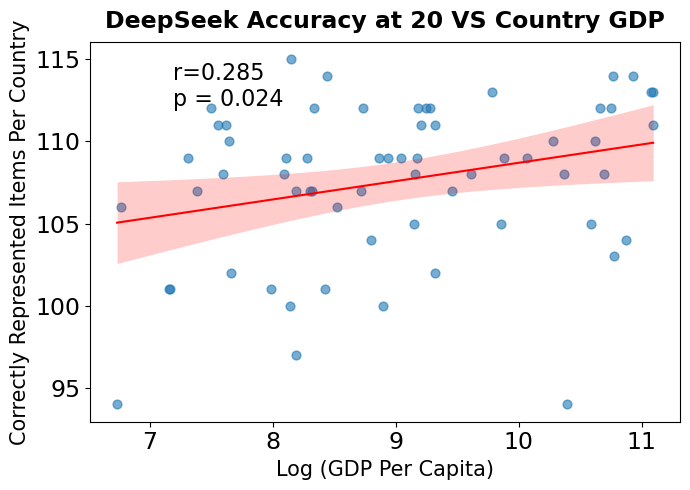

(63, 13)
[DeepSeek] Accuracy ~ log(GDP_avg)
  r=0.466, p < .001
  slope=2.290, intercept=81.583


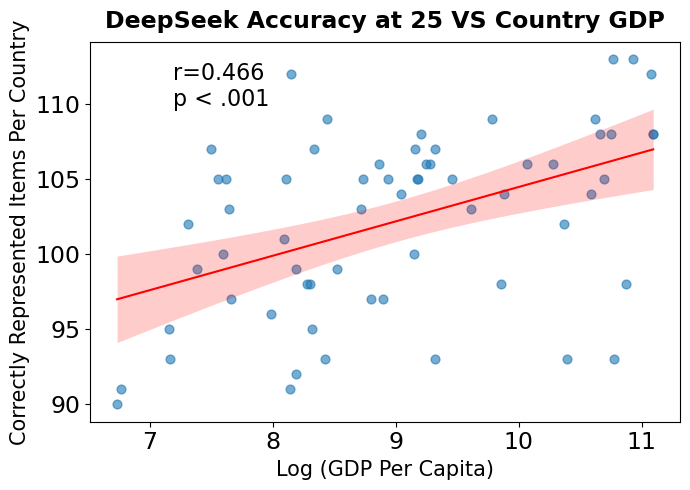

(63, 13)
[DeepSeek] Accuracy ~ log(GDP_avg)
  r=0.420, p < .001
  slope=2.361, intercept=74.391


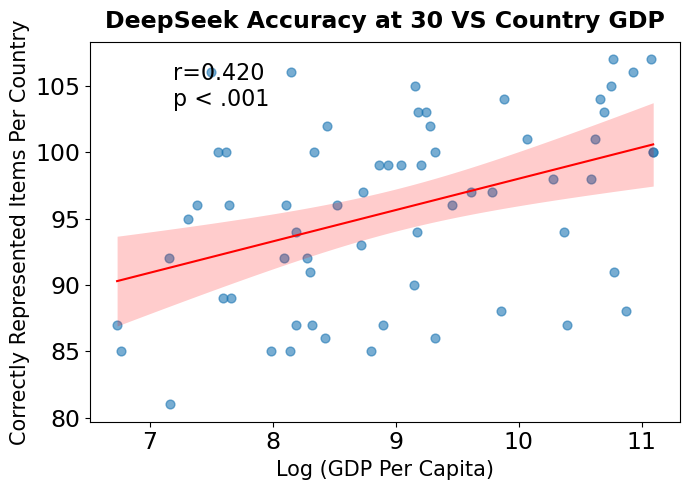

(63, 13)
[DeepSeek] Accuracy ~ log(GDP_avg)
  r=0.484, p < .001
  slope=3.044, intercept=51.167


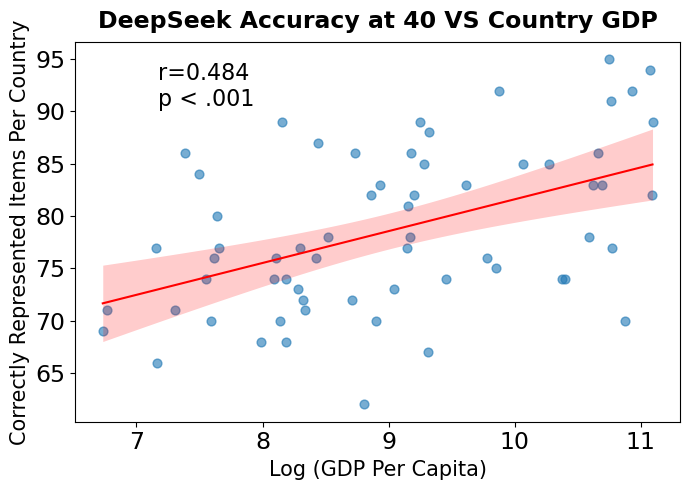

In [45]:
for thresh, df_error_byCtry in zip([10, 20, 25, 30, 40] ,
                                   [df_error_byCtry_10, df_error_byCtry_20, df_error_byCtry_25, df_error_byCtry_30, df_error_byCtry_40]):
    check_GDP_effect(thresh, df_error_byCtry, 'log(GDP_avg)')

[DeepSeek] Accuracy ~ Cultural Distance to US
  n=50, r=-0.194, p = 0.177
  slope=-10.168, intercept=115.795


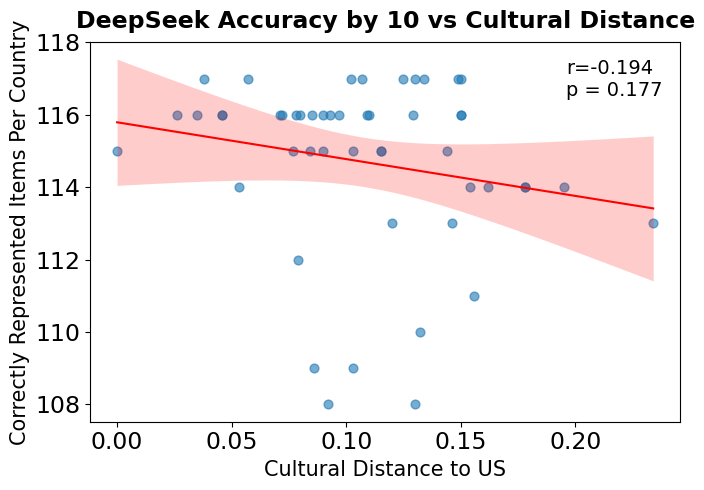

[DeepSeek] Accuracy ~ Cultural Distance to US
  n=50, r=-0.255, p = 0.074
  slope=-27.941, intercept=110.829


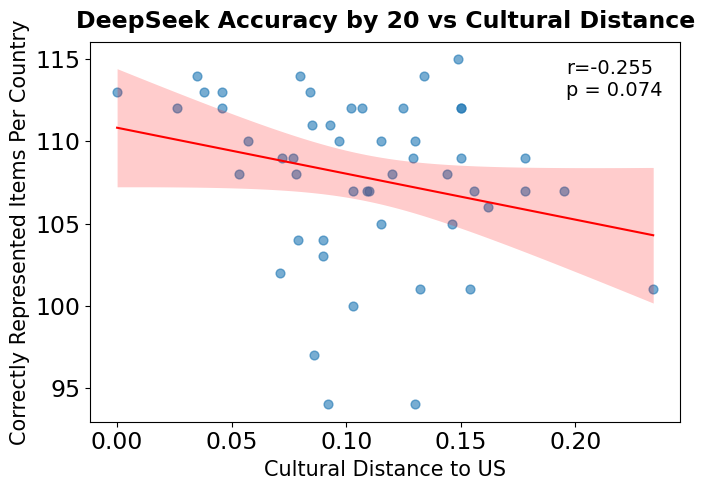

[DeepSeek] Accuracy ~ Cultural Distance to US
  n=50, r=-0.414, p = 0.003
  slope=-54.136, intercept=108.570


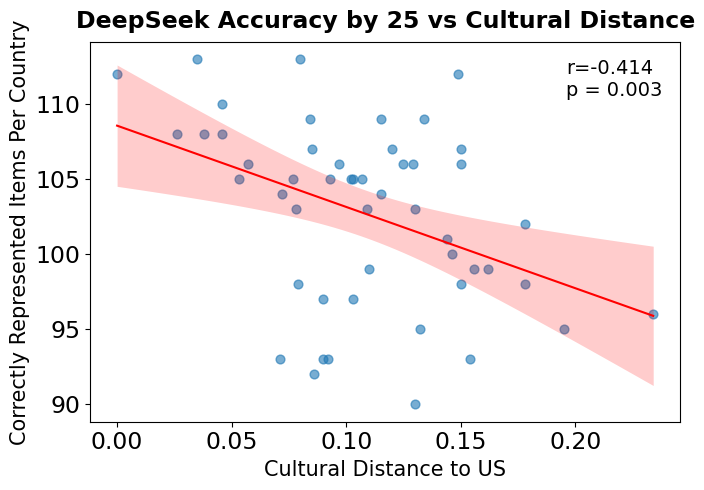

[DeepSeek] Accuracy ~ Cultural Distance to US
  n=50, r=-0.399, p = 0.004
  slope=-58.058, intercept=102.673


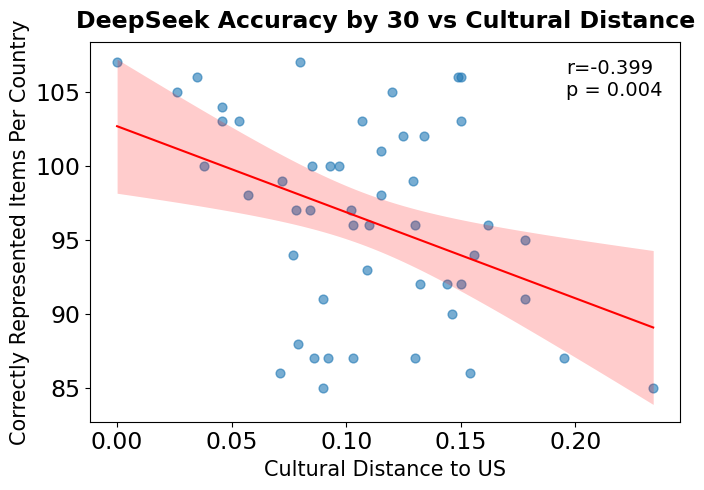

[DeepSeek] Accuracy ~ Cultural Distance to US
  n=50, r=-0.395, p = 0.005
  slope=-65.543, intercept=86.399


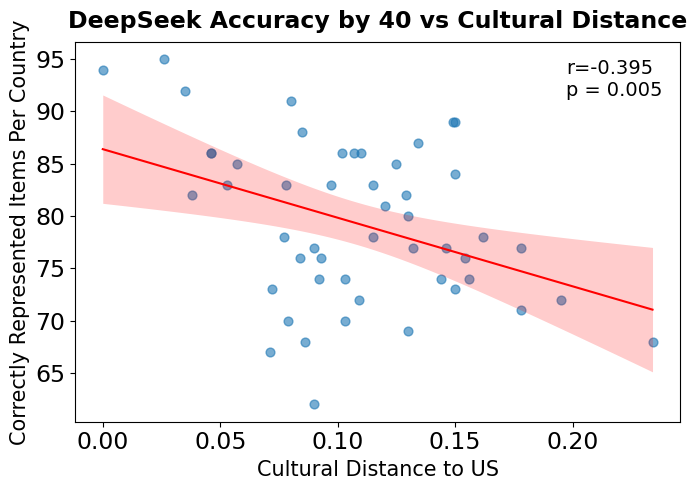

In [46]:
for thresh, df_error_byCtry in zip([10, 20, 25, 30, 40] ,
                                   [df_error_byCtry_10, df_error_byCtry_20, df_error_byCtry_25, df_error_byCtry_30, df_error_byCtry_40]):
    check_culturedist_effect(thresh, df_error_byCtry, df_culture_dist)
    

In [47]:
summarize_error()

,misrepresentation,under_estimate (by ctry),over_estimate (by ctry),under_estimate (by item),over_estimate (by item)
threshold,,,,,
10,2,1,2,0,1
20,9,3,7,1,4
25,15,5,10,3,6
30,21,7,14,4,8
40,38,15,24,8,13


In [48]:
df_percentile = calculate_response_percentile()

In [49]:
df_dev_byCtry, df_dev_byItem = organize_error_bydev()

In [50]:
r_ctry, p_ctry = pearsonr(df_error_byCtry_25['accuracy'], df_dev_byCtry['accuracy'])
r_item, p_item = pearsonr(df_error_byItem_25['accuracy'], df_dev_byItem['accuracy'])

print(r_ctry.round(3), p_ctry.round(3), r_item.round(3), p_item.round(3))

0.763 0.0 0.72 0.0


(63, 13)
[DeepSeek] Accuracy ~ log(GDP_avg)
  r=0.055, p = 0.670
  slope=0.001, intercept=0.305


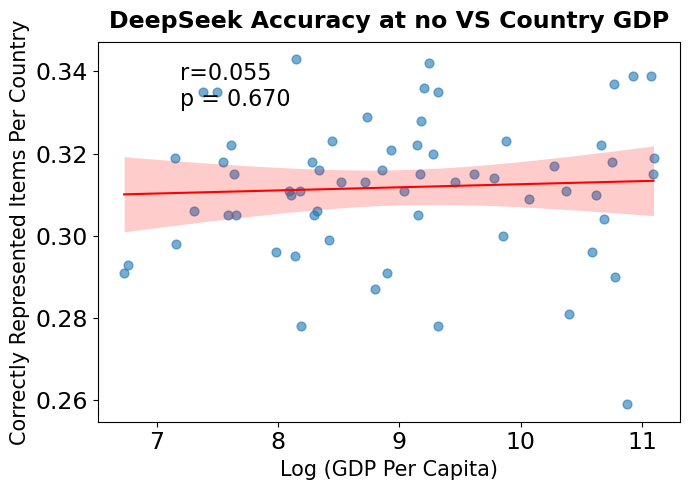

In [51]:
check_GDP_effect('no', df_dev_byCtry, 'log(GDP_avg)')

[DeepSeek] Accuracy ~ Cultural Distance to US
  n=50, r=-0.094, p = 0.516
  slope=-0.037, intercept=116.817


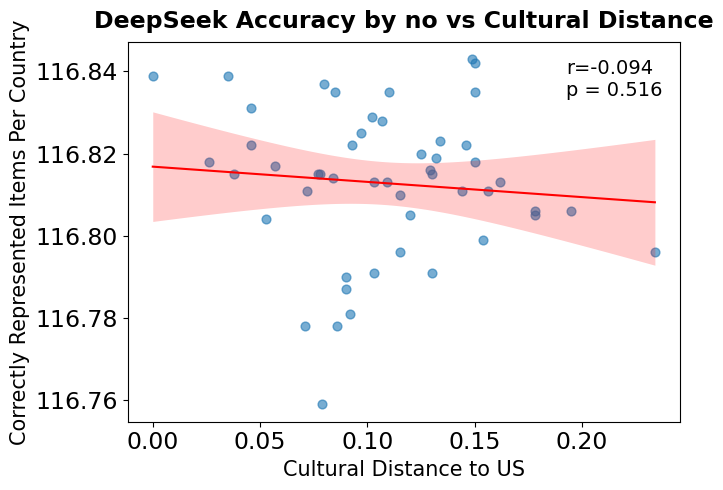

In [52]:
check_culturedist_effect("no", df_dev_byCtry, df_culture_dist)

In [53]:
# summarize error
print(
    f"average deviation: {round(df_dev_byCtry['misrepresentation'].mean(), 3)}, "
    f"under_estimate (by ctry): {round(df_dev_byCtry['under_estimate'].mean(), 3)}, "
    f"over_estimate (by ctry): {round(df_dev_byCtry['over_estimate'].mean(), 3)}, "
    f"under_estimate (by item): {round(df_dev_byItem['under_estimate'].mean(), 3)}, "
    f"over_estimate (by item): {round(df_dev_byItem['over_estimate'].mean(), 3)}"
)


average deviation: 0.188, under_estimate (by ctry): -0.174, over_estimate (by ctry): 0.2, under_estimate (by item): -0.163, over_estimate (by item): 0.19


-----------------------the end -----------------------